# V55 Pro: No Graph (Smart Greedy Selection)

Notebook ini adalah variasi dari V55 Pro, di mana kita **menghilangkan dependensi Graph Theory (NetworkX)**.

### Mengapa Tanpa Graph?
Algoritma *Maximum Independent Set* (MIS) itu berat dan kompleks. Kita bisa mencapai tujuan yang sama (Diversifikasi + Momentum) dengan pendekatan **Greedy Sederhana**:

### Logika Baru: Smart Greedy Selection
1. **Urutkan Aset** berdasarkan Momentum (Return Rata-rata) dari Tinggi ke Rendah.
2. **Iterasi** dari aset terbaik:
   - Pilih aset pertama (Pasti momentum terbaik).
   - Untuk aset berikutnya, cek apakah korelasinya dengan aset yang *sudah dipilih* rendah (< 0.4).
   - Jika rendah, masukan ke portofolio. Jika tinggi, buang.
3. Ulangi sampai semua aset dicek.

**Hasil:** Kita mendapatkan portofolio yang berisi aset-aset berkinerja terbaik yang tidak saling berkorelasi, tanpa perlu membangun graph.

### Fitur Strategi:
- **Smart Asset Selection (No-Graph):** Greedy berdasarkan Momentum.
- **AI + Trend Override (SMA 50):** Sama seperti V54/V55, menjaga posisi saat bullish.
- **Markowitz Optimization:** Menentukan bobot optimal.

In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import minimize
import xgboost as xgb
from sklearn.metrics import fbeta_score
import random
import warnings
warnings.filterwarnings('ignore')
plt.style.use('ggplot')

# --- LOCK RANDOMNESS ---
SEED = 42
np.random.seed(SEED)
random.seed(SEED)

# --- 1. Load Data ---
file_path = 'data_lq45_2023_2025.xlsx'
if not os.path.exists(file_path):
    file_path = 'dataset_2023_2025.xlsx'

data = pd.read_excel(file_path, index_col=0, parse_dates=True)
returns = data.pct_change().dropna()
market_return = returns.mean(axis=1)
market_index = (1 + market_return).cumprod() * 100

print(f"Data Loaded: {len(data)} rows")

Data Loaded: 712 rows


In [2]:
# --- 2. AI Training (Standard V47) ---
features = pd.DataFrame(index=returns.index)
features['Vol_20'] = market_return.rolling(window=20).std()
features['Mom_20'] = market_return.rolling(window=20).mean()
features['Mom_50'] = market_return.rolling(window=50).mean()

sma5 = market_return.rolling(window=5).mean()
sma20 = market_return.rolling(window=20).mean()
target = (sma5 > sma20).astype(int).shift(-5).reindex(features.index).fillna(0)

X_train = features.loc[features.index.year <= 2024].dropna()
y_train = target.loc[X_train.index]
X_test = features.loc[features.index.year == 2025]

xgb_model = xgb.XGBClassifier(n_estimators=100, learning_rate=0.05, max_depth=5, random_state=SEED, eval_metric='logloss')
xgb_model.fit(X_train, y_train)

train_probs = xgb_model.predict_proba(X_train)[:, 1]
opt_t = np.linspace(0.3, 0.7, 41)[np.argmax([fbeta_score(y_train, (train_probs >= t).astype(int), beta=0.5) for t in np.linspace(0.3, 0.7, 41)])]
test_probs = pd.Series(xgb_model.predict_proba(X_test)[:, 1], index=X_test.index)

print(f"Optimized Threshold: {opt_t:.2f}")

Optimized Threshold: 0.54


In [3]:
# --- 3. Core Logic: No-Graph Smart Selection ---

def get_smart_uncorrelated_assets(returns_window, correlation_threshold=0.4):
    """
    Selects assets using a Greedy approach without Graph Theory.
    1. Sort by Momentum (Desc).
    2. Pick if uncorrelated with ALREADY selected assets.
    """
    corr_mat = returns_window.corr()
    # 1. Momentum Sorting
    momentum = returns_window.mean()
    sorted_assets = list(momentum.sort_values(ascending=False).index)
    
    selected = []
    
    # 2. Greedy Selection
    for asset in sorted_assets:
        is_uncorrelated = True
        for selected_asset in selected:
            if abs(corr_mat.loc[asset, selected_asset]) > correlation_threshold:
                is_uncorrelated = False
                break
        
        if is_uncorrelated:
            selected.append(asset)
            
    return selected

def optimize_markowitz(selected_returns):
    if len(selected_returns.columns) == 0: return {}
    if len(selected_returns.columns) == 1: return {selected_returns.columns[0]: 1.0}
    
    mu, sigma = selected_returns.mean() * 252, selected_returns.cov() * 252
    num_assets = len(mu)

    def objective(w):
        ret = np.sum(w * mu)
        risk = np.sqrt(np.dot(w.T, np.dot(sigma, w)))
        if risk < 0.0001: return 0
        return -(ret / risk)

    constraints = ({'type': 'eq', 'fun': lambda x: np.sum(x) - 1})
    bounds = tuple((0, 1) for _ in range(num_assets))
    init_guess = [1./num_assets] * num_assets

    res = minimize(objective, init_guess, method='SLSQP', bounds=bounds, constraints=constraints)
    return dict(zip(selected_returns.columns, res.x)) if res.success else {}

def run_simulation_no_graph(test_dates, returns, ai_probs, threshold, market_idx, 
                          override_ma=None, 
                          fee=0.0025, 
                          g_lookback=60, 
                          rebal_period=20, 
                          turnover_buffer=0.05):
    val = 100.0
    history = [val]
    dates = [test_dates[0]]
    
    current_weights = {} 
    risk_status = False 
    
    days_since_rebal = 999
    market_ma = None
    if override_ma:
        market_ma = market_idx.rolling(window=override_ma).mean()
    
    for i, date in enumerate(test_dates[:-1]):
        prev_risk_status = risk_status
        prob = ai_probs.loc[date]
        
        # AI Signal
        ai_signal = False
        if not risk_status and prob > (threshold + 0.05): ai_signal = True
        elif risk_status and prob < (threshold - 0.05): ai_signal = False
        else: ai_signal = risk_status 
        
        # Trend Override
        final_signal = ai_signal
        if override_ma and market_ma is not None:
            try:
                if (market_idx.loc[date] > market_ma.loc[date]) and (not ai_signal):
                    final_signal = True # Override
            except: pass
        
        risk_status = final_signal
        regime_changed = (risk_status != prev_risk_status)
        
        target_weights = current_weights.copy()
        
        if not risk_status:
            if regime_changed or 'CASH' not in current_weights or current_weights.get('CASH', 0) < 0.99:
                target_weights = {'CASH': 1.0}
                days_since_rebal = 0
        else:
            if regime_changed or days_since_rebal >= rebal_period:
                loc_idx = returns.index.get_loc(date)
                window_rets = returns.iloc[loc_idx-g_lookback:loc_idx]
                
                # USE NO-GRAPH SELECTION HERE
                selected = get_smart_uncorrelated_assets(window_rets)
                
                optimized_weights = optimize_markowitz(window_rets[selected])
                
                all_keys = set(list(optimized_weights.keys()) + list(current_weights.keys()))
                turnover_est = sum(abs(optimized_weights.get(k, 0) - current_weights.get(k, 0)) for k in all_keys)
                if regime_changed or turnover_est > turnover_buffer:
                    target_weights = optimized_weights
                    days_since_rebal = 0
            days_since_rebal += 1

        # Execution
        all_keys_exec = set(list(target_weights.keys()) + list(current_weights.keys()))
        turnover_actual = sum(abs(target_weights.get(k, 0) - current_weights.get(k, 0)) for k in all_keys_exec)
        if turnover_actual > 0.001:
            val -= val * turnover_actual * fee
        
        next_date = test_dates[i+1]
        day_ret = 0
        new_weights = {}
        if 'CASH' in target_weights and target_weights['CASH'] > 0.99:
            day_ret = 0
            new_weights = {'CASH': 1.0}
        else:
            for asset, w in target_weights.items():
                if asset in returns.columns:
                    r = returns.loc[next_date, asset]
                    r_asset = r if not pd.isna(r) else 0
                    day_ret += w * r_asset
                    new_weights[asset] = w * (1 + r_asset)
                else:
                    new_weights[asset] = w
            sum_w = sum(new_weights.values())
            if sum_w > 0: new_weights = {k: v/sum_w for k, v in new_weights.items()}
        
        val *= (1 + day_ret)
        history.append(val)
        dates.append(next_date)
        current_weights = new_weights
    
    return pd.DataFrame({'Portfolio_Value': history}, index=dates)

Running V55 Pro (No Graph) Sim...


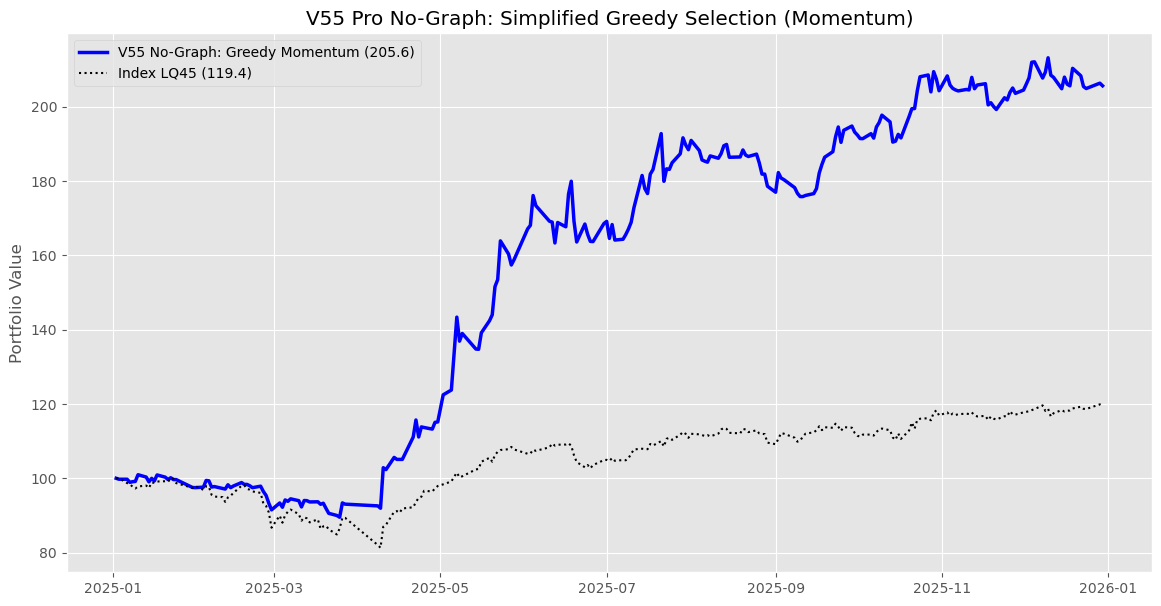

In [4]:
# --- 4. Compare V55 (No-Graph) vs Index ---

print("Running V55 Pro (No Graph) Sim...")
v55_no_graph_sim = run_simulation_no_graph(test_dates=X_test.index, returns=returns, ai_probs=test_probs, threshold=opt_t, market_idx=market_index, override_ma=50)

lq45_idx = market_index.loc[X_test.index] / market_index.loc[X_test.index[0]] * 100

plt.figure(figsize=(14, 7))
plt.plot(v55_no_graph_sim.index, v55_no_graph_sim['Portfolio_Value'], label=f'V55 No-Graph: Greedy Momentum ({v55_no_graph_sim.iloc[-1].values[0]:.1f})', linewidth=2.5, color='blue')
plt.plot(lq45_idx.index, lq45_idx, label=f'Index LQ45 ({lq45_idx.iloc[-1]:.1f})', linestyle=':', color='black')

plt.title('V55 Pro No-Graph: Simplified Greedy Selection (Momentum)')
plt.ylabel('Portfolio Value')
plt.legend()
plt.show()